**Fuzzy Clustering**

In [4]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt

np.random.seed(0)
center = 0.5
spread = 0.1

data = center+spread * np.random.randn(2, 100)
data = np.clip(data, 0, 1)

In [5]:
n_cluster = 3
m = 1.7
error = 1e-5
maxiter = 2000

In [7]:
cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
  data, c=n_cluster, m=m, error=error, maxiter=maxiter, init=None
)

hard_clusters = np.argmax(u, axis=0)

In [9]:
print("Cluster Centers:\n", cntr)
print("\nFuzzy Membership Matrix (first 5 data points):")
print(u[:, :5])

Cluster Centers:
 [[0.40427945 0.44688713]
 [0.53151691 0.61555507]
 [0.57608358 0.43108735]]

Fuzzy Membership Matrix (first 5 data points):
[[0.07539451 0.10300807 0.0304129  0.09668829 0.07004985]
 [0.75881069 0.02781874 0.01748859 0.5400935  0.07729704]
 [0.1657948  0.86917319 0.95209851 0.36321821 0.8526531 ]]


**visualzing fuzzy membership and hard cluster**

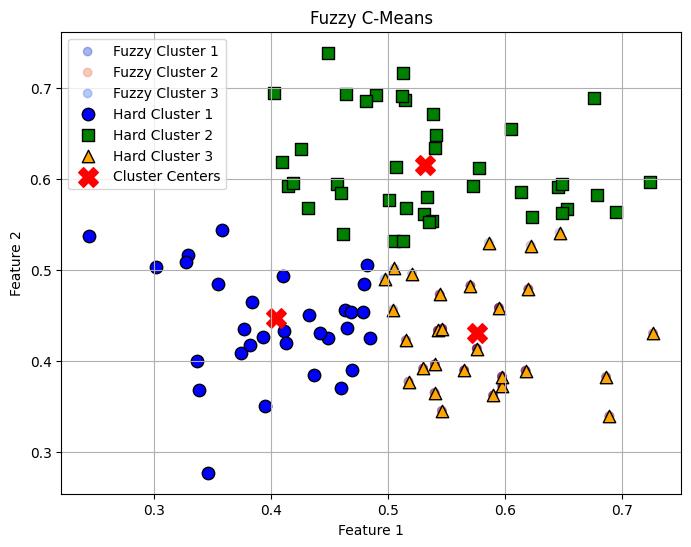

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_cluster):
  ax.scatter(data[0], data[1], c=u[i], cmap='coolwarm',
    alpha=0.5, label=f'Fuzzy Cluster {i+1}')

markers = ['o', 's', '^']
colors = ['blue', 'green', 'orange']
for i in range(n_cluster):
  cluster_points = data[:, hard_clusters == i]
  ax.scatter(cluster_points[0], cluster_points[1], c=colors[i],
    marker=markers[i], edgecolor='k', s=80, label=f'Hard Cluster {i+1}')

ax.scatter(cntr[:, 0], cntr[:, 1], c='red',
marker='X', s=200, label='Cluster Centers')

ax.set_title('Fuzzy C-Means')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='upper left')
plt.grid(True)
plt.show()